# Spam Message Classification with Random Forest and SVM

## 1. Data Preprocessing

### Importing the libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Importing the dataset

In [4]:
df = pd.read_csv('spam.tsv',sep='\t')

In [5]:
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


In [6]:
df.tail()

,label,message,length,punct
5567,spam,This is the 2nd time we have tried 2 contact u...,160,8
5568,ham,Will ü b going to esplanade fr home?,36,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,7
5570,ham,The guy did some bitching but I acted like i'd...,125,1
5571,ham,Rofl. Its true to its name,26,1


In [7]:
# check null values in dataset
df.isna().sum() # if any records/rows have empty values then it will remove those records

label      0
message    0
length     0
punct      0
dtype: int64

In [8]:
df.describe() # describe numerical values of df

,length,punct
count,5572.000000,5572.000000
mean,80.489950,4.177495
std,59.942907,4.623919
min,2.000000,0.000000
25%,36.000000,2.000000
50%,62.000000,3.000000
75%,122.000000,6.000000
max,910.000000,133.000000


In [9]:
# check number of ham and spam
(df['label'].value_counts()/len(df))*100

label
ham     86.593683
spam    13.406317
Name: count, dtype: float64

In [10]:
# 4825 messages are legitimate that is ham
# and 747 messages are spam messages
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

### Balancing the data

In [12]:
# select ham and spam data
ham = df[df['label']=='ham']
spam = df[df['label']=='spam']

In [13]:
ham.shape, spam.shape

((4825, 4), (747, 4))

In [14]:
ham = ham.sample(spam.shape[0]) # to get same number of spam records 747 from ham, balancing records

In [16]:
ham.shape, spam.shape
# size of ham and spam data is same, now this is the balenced data

((747, 4), (747, 4))

In [17]:
# append spam data into ham data
#data = ham.append(spam,ignore_index=True)
data = pd.concat([ham,spam],ignore_index=True) # concat/append spam data into ham

In [18]:
data.shape

(1494, 4)

In [20]:
data.head()
# at the starting we have all the ham data

,label,message,length,punct
0,ham,Sorry i cant take your call right now. It so h...,368,10
1,ham,Where @,7,1
2,ham,As in different styles?,23,1
3,ham,I had askd u a question some hours before. Its...,53,1
4,ham,Its sarcasm.. .nt scarcasim,27,3


In [23]:
data.tail()
# at the ending we have all the spam data

,label,message,length,punct
1489,spam,Want explicit SEX in 30 secs? Ring 02073162414...,90,3
1490,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,158,5
1491,spam,Had your contract mobile 11 Mnths? Latest Moto...,160,8
1492,spam,REMINDER FROM O2: To get 2.50 pounds free call...,147,3
1493,spam,This is the 2nd time we have tried 2 contact u...,160,8


### Data Visualization

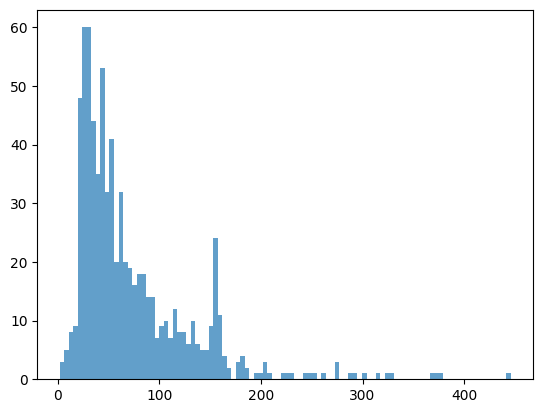

In [31]:
# plot histogram of length for ham messages
plt.hist(data[data['label']=='ham']['length'], bins=100, alpha=0.7)
plt.show()
# from the histogram we can say that, the number of charactors in ham messages are less than 100

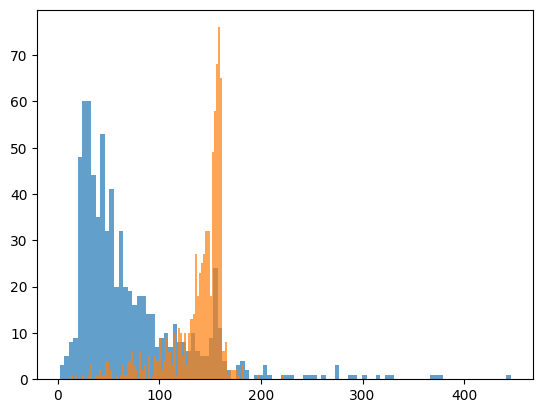

In [32]:
# plot histogram of length for ham and spam both
plt.hist(data[data['label']=='ham']['length'],bins=100,alpha=0.7)
plt.hist(data[data['label']=='spam']['length'],bins=100,alpha=0.7)
plt.show()
# x - length, y-frequency

In [33]:
# It looks like there's a small range of values where a message is more likely to be spam than ham

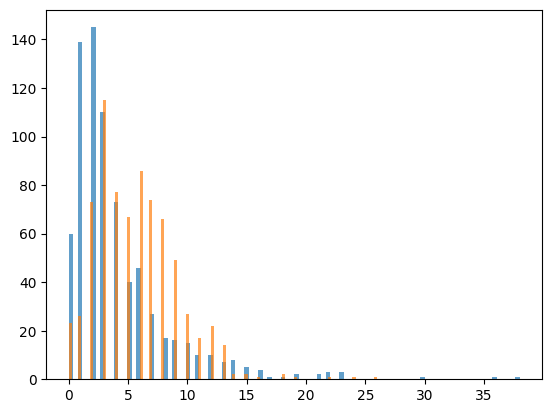

In [34]:
plt.hist(data[data['label']=='ham']['punct'],bins=100,alpha=0.7)
plt.hist(data[data['label']=='spam']['punct'],bins=100,alpha=0.7)
plt.show()

In [36]:
data

,label,message,length,punct
0,ham,Sorry i cant take your call right now. It so h...,368,10
1,ham,Where @,7,1
2,ham,As in different styles?,23,1
3,ham,I had askd u a question some hours before. Its...,53,1
4,ham,Its sarcasm.. .nt scarcasim,27,3
...,...,...,...,...
1489,spam,Want explicit SEX in 30 secs? Ring 02073162414...,90,3
1490,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,158,5
1491,spam,Had your contract mobile 11 Mnths? Latest Moto...,160,8
1492,spam,REMINDER FROM O2: To get 2.50 pounds free call...,147,3


### Split the data into train and test sets

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train,X_test,y_train,y_test = train_test_split(data['message'],data['label'],test_size=0.3,random_state=0,shuffle=True)

In [39]:
1494*0.3

448.2

In [40]:
X_train.shape

(1045,)

In [41]:
X_test.shape

(449,)

In [42]:
X_train

1438      You have 1 new message. Please call 08715205273
431     Goodnight, sleep well da please take care pa. ...
194     Honey ? Sweetheart ? Darling ? Sexy buns ? Sug...
240                                      Okie... Thanx...
1309    Had your mobile 11 months or more? U R entitle...
                              ...                        
763     Your free ringtone is waiting to be collected....
835     XCLUSIVE@CLUBSAISAI 2MOROW 28/5 SOIREE SPECIAL...
1216    Dorothy@kiefer.com (Bank of Granite issues Str...
559     Wah... Okie okie... Muz make use of e unlimite...
684     Two fundamentals of cool life: "Walk, like you...
Name: message, Length: 1045, dtype: object

In [43]:
y_train

1438    spam
431      ham
194      ham
240      ham
1309    spam
        ... 
763     spam
835     spam
1216    spam
559      ham
684      ham
Name: label, Length: 1045, dtype: object

## 2. Building the model Random Forest

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [45]:
classifier = Pipeline([('tfidf',TfidfVectorizer()),('classifier',RandomForestClassifier(n_estimators=100))])

In [46]:
classifier.fit(X_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier', RandomForestClassifier())])

## 3. Predicting the results random forest

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [51]:
y_pred = classifier.predict(X_test)

In [52]:
# confusion_matrix
confusion_matrix(y_test, y_pred)

array([[223,   4],
       [ 24, 198]])

In [53]:
# ham and spam
# spam and ham

In [54]:
# classification_report
print(classification_report(y_test, y_pred))
# we are getting almost 94% accuracy

              precision    recall  f1-score   support

         ham       0.90      0.98      0.94       227
        spam       0.98      0.89      0.93       222

    accuracy                           0.94       449
   macro avg       0.94      0.94      0.94       449
weighted avg       0.94      0.94      0.94       449



In [55]:
accuracy_score(y_test, y_pred)
# 93.76% accuracy

0.9376391982182628

In [56]:
0.9376391982182628 * 449

421.0

In [57]:
test1 = ['Hello, You are learning natural Language Processing']
test2 = ['Hope you are doing good and learning new things !']
test3 = ['Congratulations, You won a lottery ticket worth $1 Million ! To claim call on 446677']

In [58]:
print(classifier.predict(test1))
print(classifier.predict(test2))
print(classifier.predict(test3))

['ham']
['ham']
['spam']


## 4. Building the SVM

In [59]:
from sklearn.svm import SVC

In [60]:
svm = Pipeline([('tfidf',TfidfVectorizer()),('classifier',SVC(C=100,gamma='auto'))])

In [61]:
svm.fit(X_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier', SVC(C=100, gamma='auto'))])

## 5. predicting the results of svm

In [62]:
y_pred = svm.predict(X_test)

In [63]:
y_test, y_pred

(799     spam
 1047    spam
 1436    spam
 54       ham
 793     spam
         ... 
 824     spam
 822     spam
 644      ham
 1034    spam
 1356    spam
 Name: label, Length: 449, dtype: object,
 array(['spam', 'spam', 'spam', 'ham', 'spam', 'spam', 'ham', 'ham', 'ham',
        'ham', 'spam', 'ham', 'ham', 'spam', 'spam', 'spam', 'spam', 'ham',
        'spam', 'spam', 'spam', 'ham', 'spam', 'spam', 'ham', 'spam',
        'ham', 'ham', 'spam', 'ham', 'ham', 'spam', 'spam', 'spam', 'spam',
        'spam', 'ham', 'spam', 'ham', 'ham', 'spam', 'ham', 'spam', 'ham',
        'ham', 'spam', 'ham', 'ham', 'spam', 'spam', 'ham', 'ham', 'spam',
        'spam', 'spam', 'spam', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham',
        'ham', 'spam', 'spam', 'ham', 'ham', 'ham', 'spam', 'spam', 'spam',
        'spam', 'spam', 'ham', 'ham', 'spam', 'spam', 'ham', 'ham', 'ham',
        'ham', 'ham', 'ham', 'ham', 'ham', 'spam', 'spam', 'ham', 'spam',
        'ham', 'ham', 'spam', 'ham', 'ham', 'spam', 'spa

In [64]:
accuracy_score(y_test,y_pred)

0.933184855233853

In [65]:
confusion_matrix(y_test, y_pred)

array([[221,   6],
       [ 24, 198]])

In [66]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.90      0.97      0.94       227
        spam       0.97      0.89      0.93       222

    accuracy                           0.93       449
   macro avg       0.94      0.93      0.93       449
weighted avg       0.94      0.93      0.93       449



In [70]:
print(svm.predict(test1))
print(svm.predict(test2))
print(svm.predict(test3))

['ham']
['ham']
['spam']
